## Support Vector Regression (SVR) – Complete Machine Learning Pipeline

## 1. Introduction

Support Vector Regression (SVR) is a machine learning algorithm derived from **Support Vector Machines (SVM)**. It is used for **regression problems**, where the goal is to predict a continuous value.

Instead of minimizing prediction errors directly, SVR tries to **fit a function within a margin of tolerance (ε)** while keeping the model as simple as possible.

### Type of ML Problem

Regression

### Real-World Applications

SVR is widely used in many domains:

* Stock price prediction
* Energy consumption forecasting
* House price prediction
* Weather forecasting
* Demand forecasting

### Why SVR is Useful

SVR is powerful because:

* Works well with **high dimensional data**
* Effective with **nonlinear relationships**
* Uses **kernel trick** to map data into higher dimensions
* Robust against overfitting

### Importing Libraries

In [36]:
# Core Libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures

# Model
from sklearn.svm import SVR

# Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Model Interpretation
import shap
from sklearn.inspection import permutation_importance
from sklearn.inspection import PartialDependenceDisplay

# Model Saving
import joblib

### Load dataset

In [40]:
data = fetch_california_housing()

In [41]:
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="price")

In [42]:
print("Dataset Shape:", X.shape)

Dataset Shape: (20640, 8)


In [43]:
display(X.head())

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


### Exploratory Data Analysis (EDA)

**Dataset Info**

In [44]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
dtypes: float64(8)
memory usage: 1.3 MB


**Missing Values**

In [45]:
print("\nMissing values:\n", X.isnull().sum())


Missing values:
 MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64


**Statistical Summary**

In [46]:
print("\nStatistical summary:\n", X.describe())


Statistical summary:
              MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude  
count  20640.000000  20640.000000  20640.000000  
mean       3.070655     35.631861   -119.569704  
std       10.386050      2.135952      2.003532  
min        0.692308     32.540000   -124.350000  
25%        2.42

**Target Distribution**

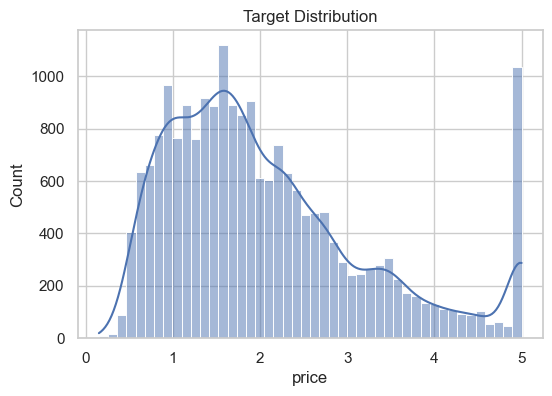

In [47]:
plt.figure(figsize=(6,4))
sns.histplot(y, kde=True)
plt.title("Target Distribution")
plt.show()

**Correlation Matrix**

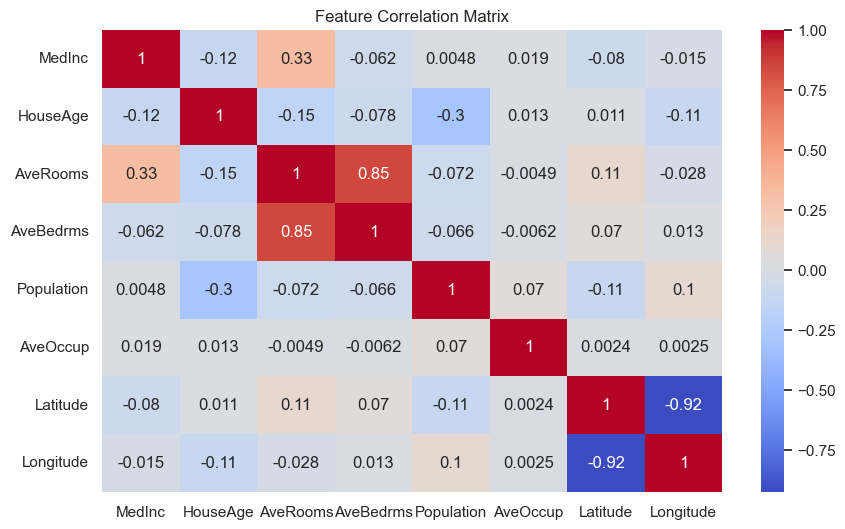

In [48]:
plt.figure(figsize=(10,6))
sns.heatmap(X.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

**Pairplot (sample)**

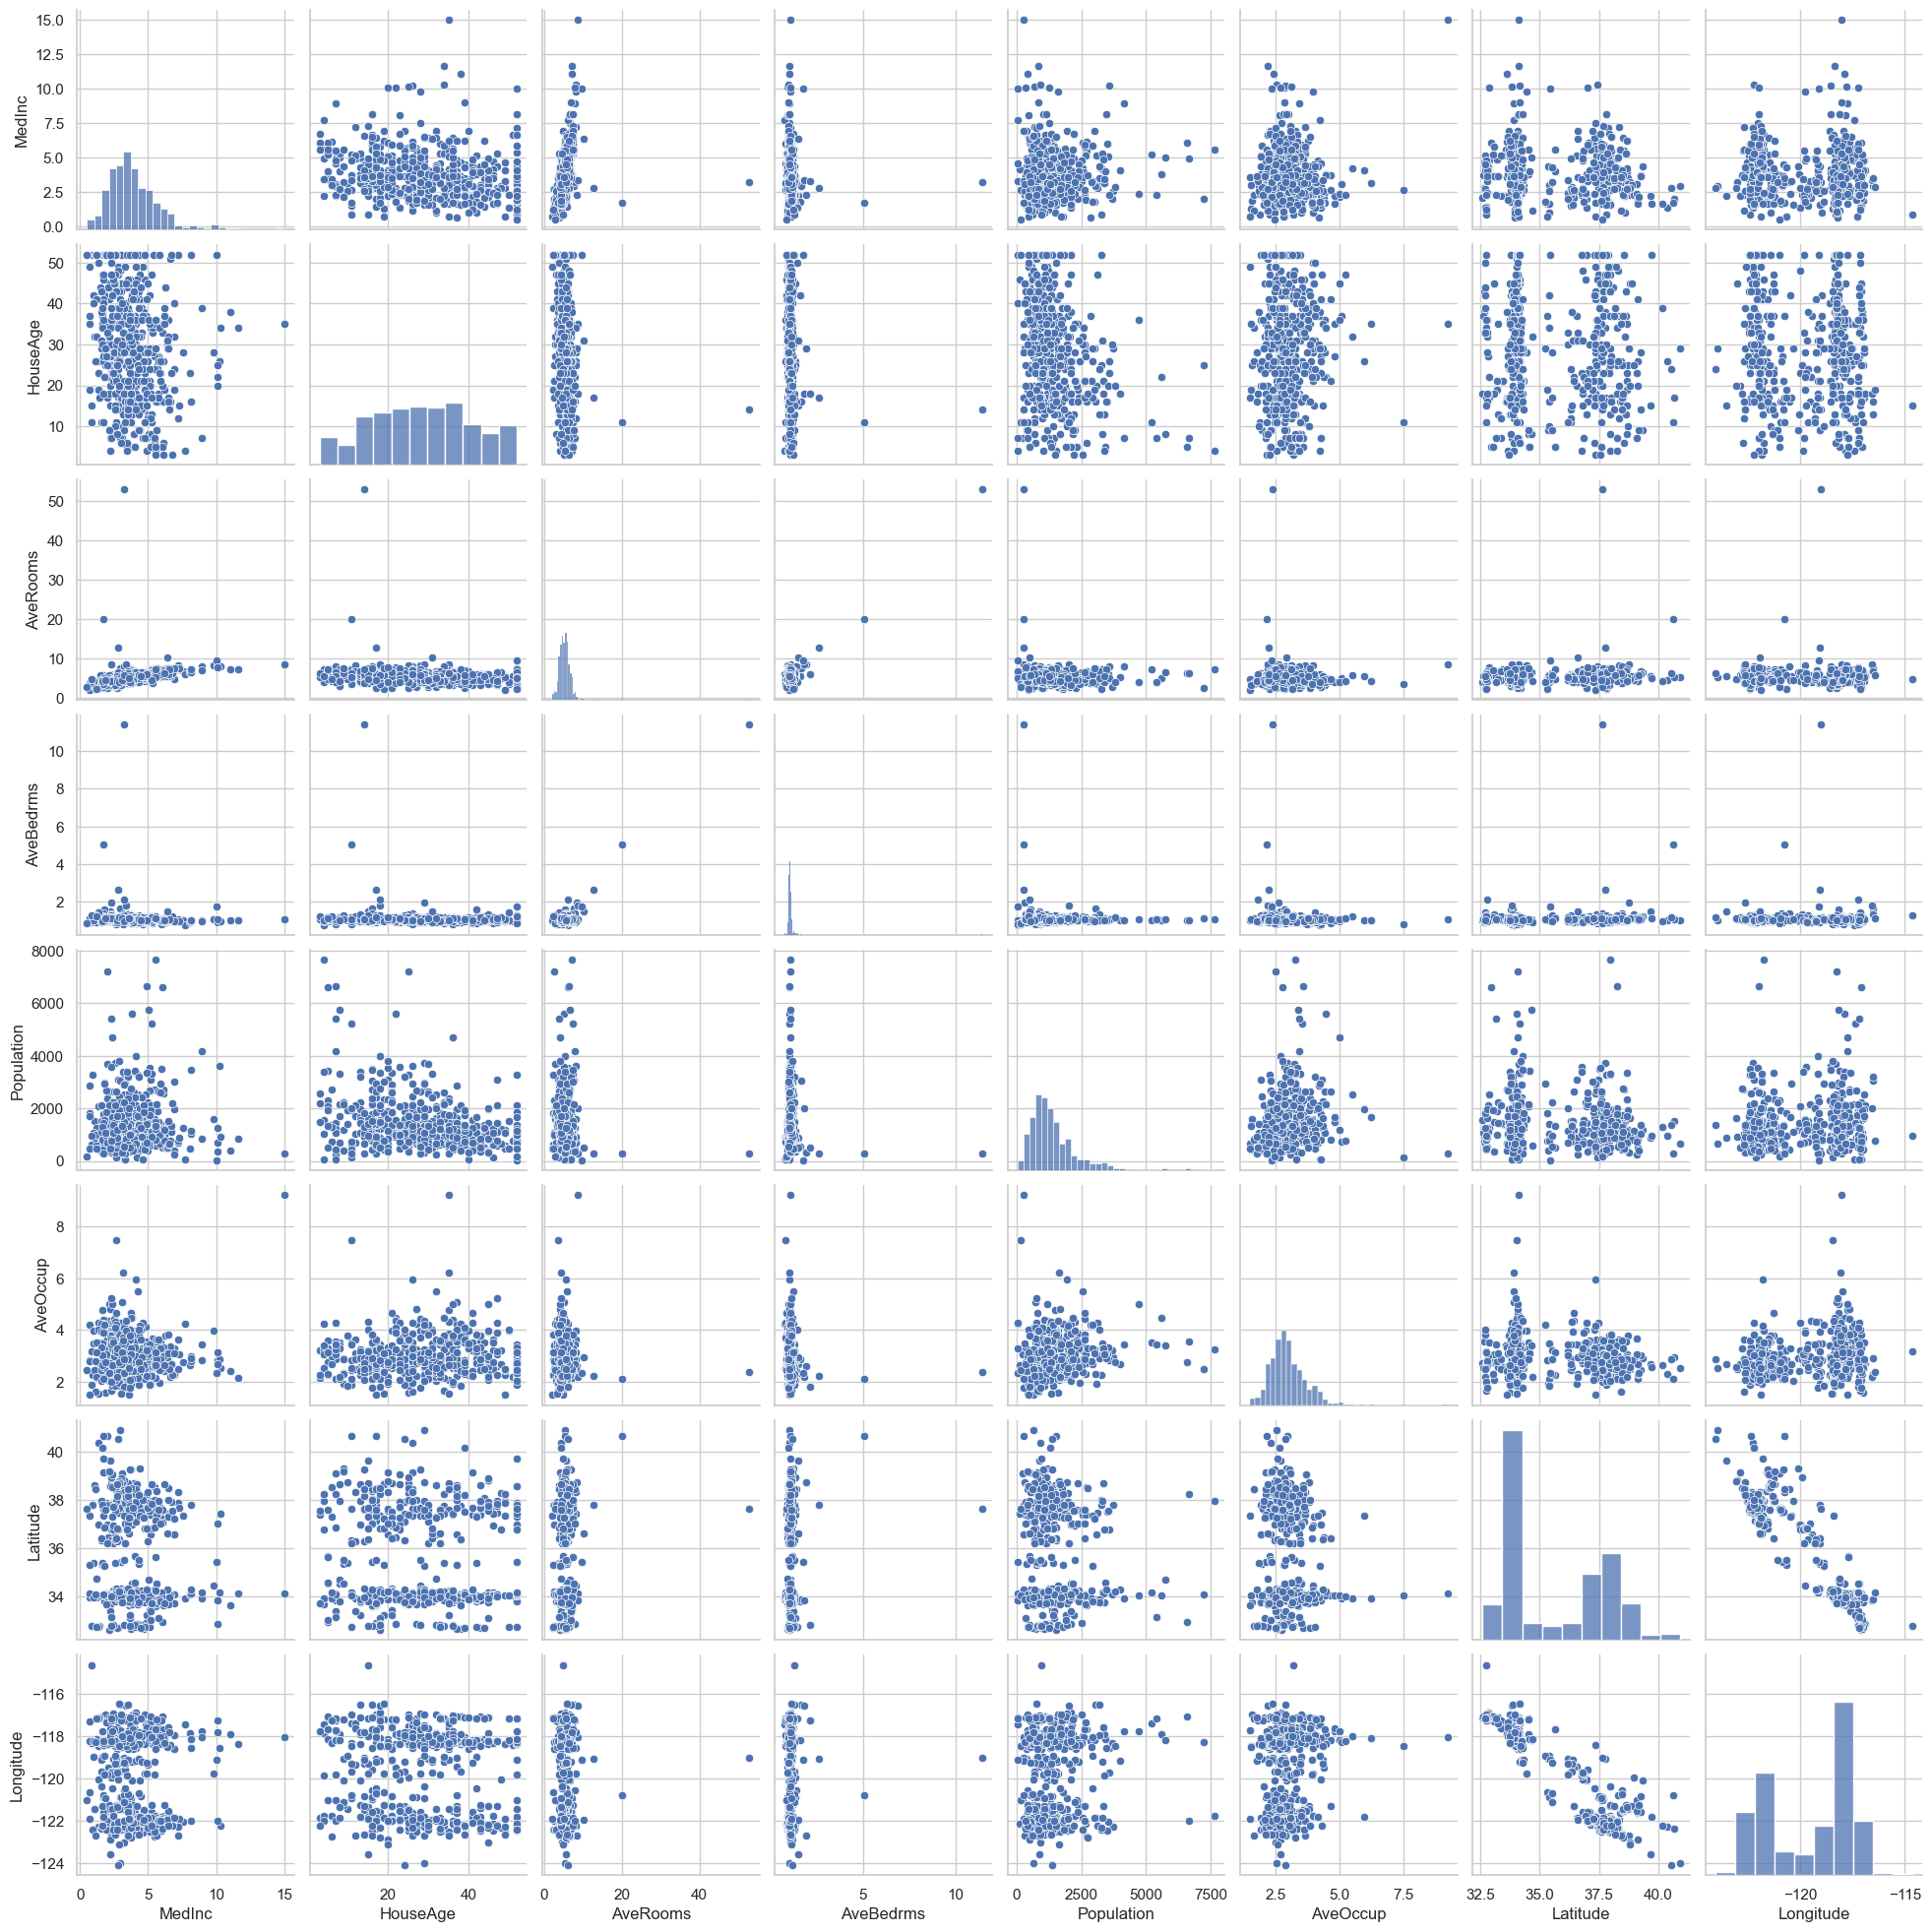

In [49]:
sns.pairplot(X.sample(500))
plt.show()

### Feature Engineering

In [50]:
poly = PolynomialFeatures(degree=2, include_bias=False)

X_poly = poly.fit_transform(X)

print("New Feature Shape:", X_poly.shape)

New Feature Shape: (20640, 44)


### Train-Test Split

In [51]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

### Machine Learning Pipeline

In [52]:
pipeline = Pipeline([
    
    ("scaler", StandardScaler()),
    
    ("model", SVR())
])

### Model Training

In [53]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('model', SVR())])

**Prediction:**

In [54]:
y_pred = pipeline.predict(X_test)

### Hyperparameter Tuning with GridSearchCV

In [55]:
param_grid = {
    
    "model__kernel": ["rbf", "linear"],
    
    "model__C": [0.1, 1, 10],
    
    "model__gamma": ["scale", "auto"],
    
    "model__epsilon": [0.1, 0.2, 0.5]
}

In [56]:
grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('model', SVR())]),
             n_jobs=-1,
             param_grid={'model__C': [0.1, 1, 10],
                         'model__epsilon': [0.1, 0.2, 0.5],
                         'model__gamma': ['scale', 'auto'],
                         'model__kernel': ['rbf', 'linear']},
             scoring='neg_mean_squared_error')

In [57]:
print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

Best Parameters: {'model__C': 10, 'model__epsilon': 0.2, 'model__gamma': 'scale', 'model__kernel': 'rbf'}
Best CV Score: -0.31871493559733166


**Best model**

In [58]:
best_model = grid.best_estimator_

### Model Evaluation

In [59]:
y_pred = best_model.predict(X_test)

In [60]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

mae = mean_absolute_error(y_test, y_pred)

r2 = r2_score(y_test, y_pred)

In [61]:
print("RMSE:", rmse)
print("MAE:", mae)
print("R2 Score:", r2)

RMSE: 0.5668094024598246
MAE: 0.37962385815265953
R2 Score: 0.7548300537835585


### Visualization of Results

**Actual vs Predicted**

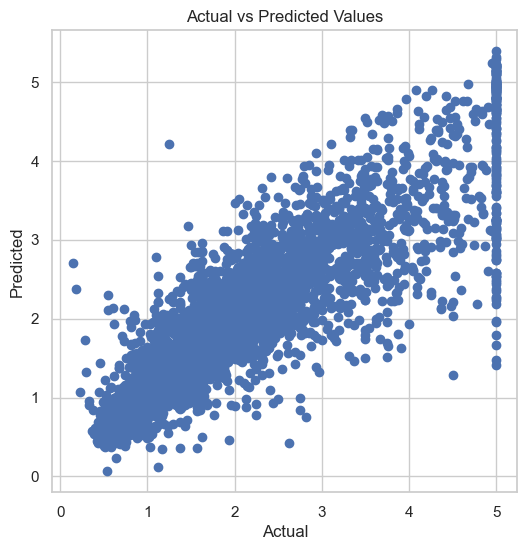

In [62]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted Values")
plt.show()

**Residual Plot**

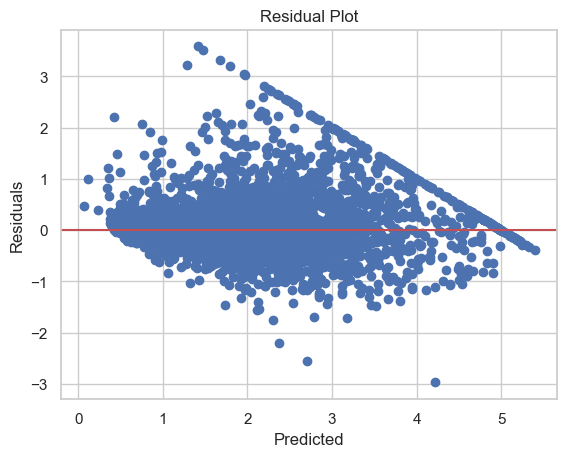

In [63]:
residuals = y_test - y_pred

plt.scatter(y_pred, residuals)

plt.axhline(y=0, color='r')

plt.xlabel("Predicted")

plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

In [64]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    best_model,
    X_train,
    y_train,
    cv=5
)

In [65]:
train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

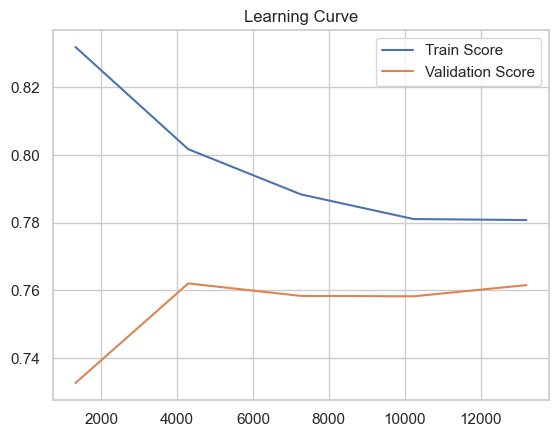

In [66]:
plt.plot(train_sizes, train_mean, label="Train Score")
plt.plot(train_sizes, test_mean, label="Validation Score")

plt.legend()
plt.title("Learning Curve")

plt.show()

### Model Explainability

**Permutation Importance**

In [67]:
result = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42
)


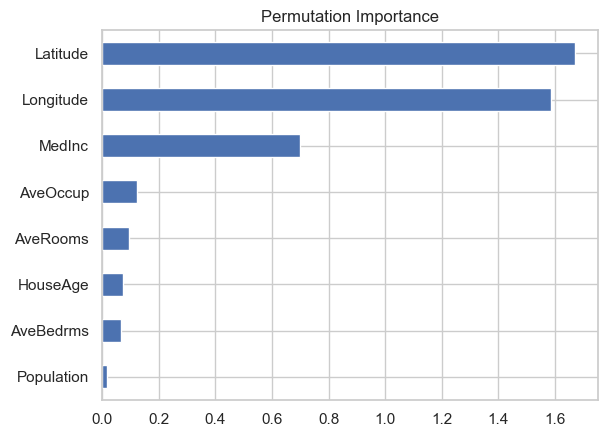

In [68]:
importance = pd.Series(
    result.importances_mean,
    index=X.columns
)

importance.sort_values().plot.barh()

plt.title("Permutation Importance")

plt.show()

**Partial Dependence Plot**

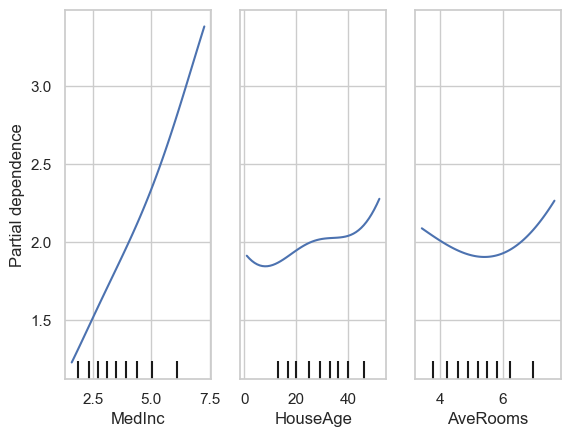

In [69]:
PartialDependenceDisplay.from_estimator(
    best_model,
    X_test,
    features=[0,1,2]
)

plt.show()

### Final Model Insights

Key observations:

* Most influential features affect house price strongly.
* SVR handles nonlinear relationships well.
* Model performance depends heavily on **kernel choice and C value**.

Possible improvements:

* Try **Kernel Ridge Regression**
* Try **XGBoost / LightGBM**
* Feature engineering
* Larger hyperparameter search



### Saving the Model

In [74]:
joblib.dump(best_model, "svr_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [75]:
model = joblib.load("svr_model.pkl")

# Model Theory: Support Vector Regression (SVR)


### 1. Algorithm Overview

SVR attempts to find a function that approximates the relationship between input features and target values while allowing a tolerance margin (ε).

Instead of minimizing squared error directly, SVR:

* Fits a **hyperplane**
* Allows errors within **ε margin**
* Penalizes points outside the margin


### 2. Mathematical Intuition

SVR tries to minimize:

$$
\frac{1}{2} ||w||^2
$$ 

Subject to:

$$
|y_i - (w \cdot x_i + b)| \le \epsilon
$$

Loss function used:

**ε-insensitive loss**

Only errors larger than ε contribute to the loss.



### 3. When to Use SVR

SVR works best when:

* Dataset size is **small to medium**
* Relationship is **nonlinear**
* Data is **high dimensional**
* Need **robust regression**


### 4. Advantages

* Works well in high dimensions
* Powerful with kernel trick
* Good generalization performance
* Robust to overfitting


### 5. Disadvantages

* Slow for very large datasets
* Sensitive to hyperparameters
* Requires feature scaling
* Hard to interpret compared to trees

